In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import kagglehub


In [6]:
#Downloading dataset
path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\iamid\.cache\kagglehub\datasets\radheshyamkollipara\bank-customer-churn\versions\1


In [7]:
dataset = pd.read_csv("Customer-Churn-Records.csv")

In [8]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [9]:
dataset.info()
dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [10]:
dataset.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [11]:
dataset['Exited'].value_counts(normalize = True)

Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64

In [12]:
dataset = dataset.drop(['RowNumber','CustomerId','Surname','Complain', 'Satisfaction Score', 'Point Earned' ], axis = 1)

In [13]:
dataset.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Card Type
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,DIAMOND
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,DIAMOND
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,DIAMOND
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,GOLD
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,GOLD


In [14]:
label = LabelEncoder()
dataset['Gender'] = label.fit_transform(dataset['Gender']) #encoding data in gender column to zeroes(female) and ones(male)

In [15]:
print(dataset['Gender'])

0       0
1       0
2       0
3       0
4       0
       ..
9995    1
9996    1
9997    0
9998    1
9999    0
Name: Gender, Length: 10000, dtype: int32


In [16]:
dataset = pd.get_dummies(dataset, columns=['Geography', 'Card Type'])

In [17]:
dataset.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Card Type_DIAMOND,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,0,42,2,0.00,1,1,1,101348.88,1,True,False,False,True,False,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True,False,False,False
2,502,0,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True,False,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,True,False,False,False,True,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,False,True,False,True,False,False


In [18]:
x = dataset.drop('Exited', axis = 1)
y = dataset['Exited']

In [19]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, stratify = y, random_state = 42)

In [20]:
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

In [21]:
model = LogisticRegression()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)



In [22]:
print("Accuracy : " , accuracy_score(y_test,y_pred))
print("\nClassification Report\n", classification_report(y_test,y_pred))

Accuracy :  0.8115

Classification Report
               precision    recall  f1-score   support

           0       0.83      0.97      0.89      1592
           1       0.61      0.21      0.31       408

    accuracy                           0.81      2000
   macro avg       0.72      0.59      0.60      2000
weighted avg       0.78      0.81      0.77      2000



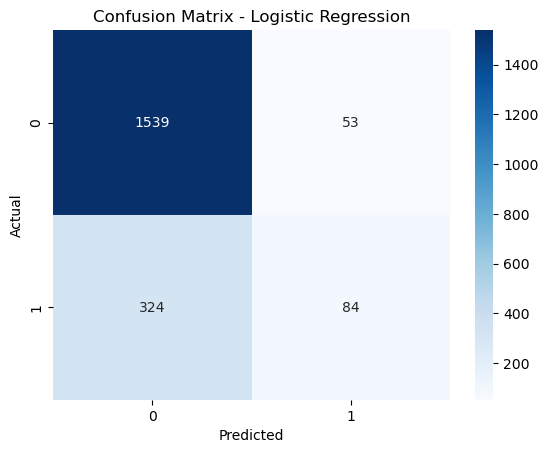

In [23]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [24]:
dataset.corr()['Exited'].sort_values(ascending=False)

Exited                1.000000
Age                   0.285296
Geography_Germany     0.173313
Balance               0.118577
Card Type_DIAMOND     0.020089
EstimatedSalary       0.012490
Card Type_PLATINUM   -0.000276
Card Type_SILVER     -0.003834
HasCrCard            -0.006976
Tenure               -0.013656
Card Type_GOLD       -0.015995
CreditScore          -0.026771
NumOfProducts        -0.047611
Geography_Spain      -0.052800
Geography_France     -0.104688
Gender               -0.106267
IsActiveMember       -0.156356
Name: Exited, dtype: float64

In [25]:
!pip install xgboost

In [26]:
from xgboost import XGBClassifier

In [27]:
xgb = XGBClassifier(
    n_estimators=200,       # number of trees
    learning_rate=0.1,      # step size shrinkage
    max_depth=4,            # depth of each tree
    subsample=0.8,          # fraction of rows used per tree
    colsample_bytree=0.8,   # fraction of features per tree
    scale_pos_weight=4,     # handle class imbalance (ratio = majority/minority)
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)


In [28]:
xgb.fit(x_train, y_train)

C:\Users\iamid\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:09:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [29]:
y_pred = xgb.predict(x_test)

In [30]:
print("Accuracy : " , accuracy_score(y_test,y_pred))
print("\nClassification Report\n", classification_report(y_test,y_pred))

Accuracy :  0.804

Classification Report
               precision    recall  f1-score   support

           0       0.93      0.82      0.87      1592
           1       0.51      0.75      0.61       408

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.84      0.80      0.82      2000



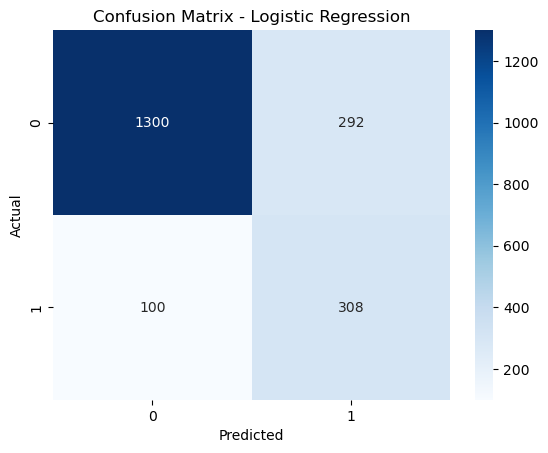

In [31]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()